# Laboratorio 06 - Telco Customer Churn
## k-NN y Regresión Logística
Notebook listo para Google Colab.

**Objetivo:** predecir churn en una empresa de telecomunicaciones y comparar k-NN vs Regresión Logística.


## Paso 1. Carga e inspección del dataset


In [ ]:
# ============================================
# LABORATORIO N° 06 - Telco Customer Churn
# k-NN y Regresión Logística
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix, roc_curve)

In [ ]:
# ============================================
# PASO 1: Carga e inspección del dataset
# ============================================

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(df.head())
print(df.isnull().sum().sort_values(ascending=False).head(10))


Dataset: 7,043 filas x 21 columnas
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV S

## Paso 2. Limpieza inicial y variable objetivo


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

print(f'Nulos en TotalCharges: {df["TotalCharges"].isna().sum()}')
print(df['Churn'].value_counts())
print(f'Proporción de Churn: {df["Churn_bin"].mean():.2%}')


Nulos en TotalCharges: 11
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Proporción de Churn: 26.54%


## Paso 3. Exploración de churn


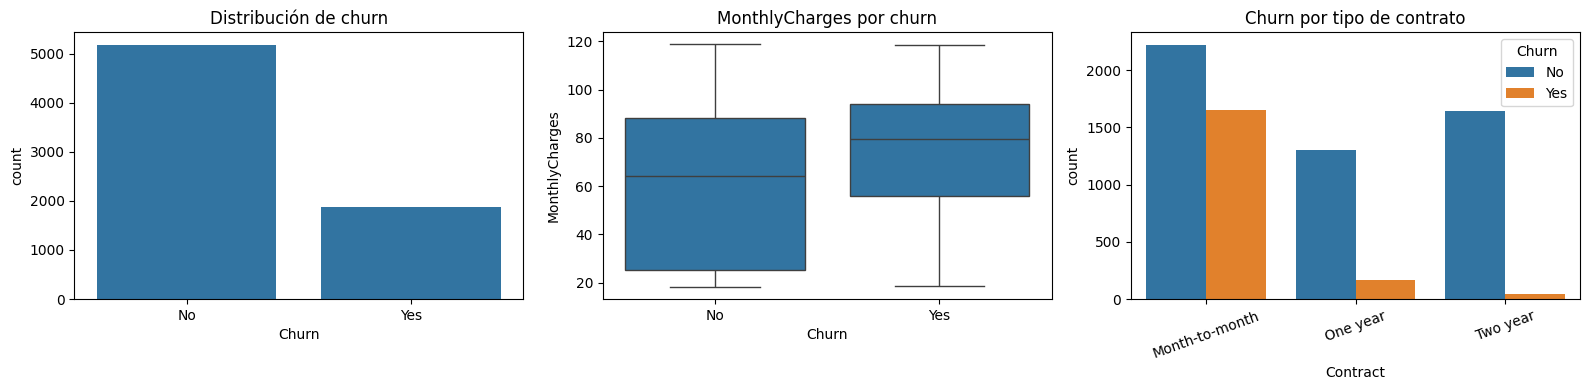

In [ ]:
# ============================================
# PASO 3: Exploración de churn
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Distribución de churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('MonthlyCharges por churn')

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2])
axes[2].set_title('Churn por tipo de contrato')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## Paso 4. Preparación de variables


In [ ]:
rop_cols = ['customerID', 'Churn']
X = df.drop(columns=drop_cols + ['Churn_bin'])
y = df['Churn_bin']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # ← CORREGIDO: cerrar paréntesis
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(4930, 19) (2113, 19)


## Paso 5. Búsqueda del k óptimo para k-NN


Mejor k: 21


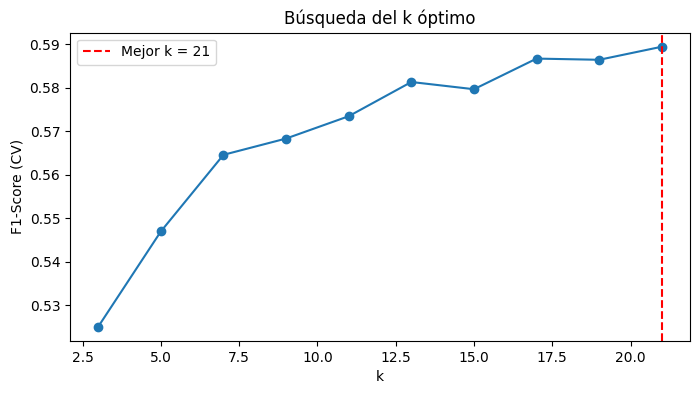

In [ ]:
k_values = list(range(3, 22, 2))
cv_f1 = []

for k in k_values:
    knn_pipe = Pipeline(steps=[
        ('prep', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    score = cross_val_score(knn_pipe, X_train, y_train, cv=5, scoring='f1').mean()
    cv_f1.append(score)

best_k = k_values[np.argmax(cv_f1)]
print(f'Mejor k: {best_k}')

plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_f1, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Mejor k = {best_k}')
plt.title('Búsqueda del k óptimo')
plt.xlabel('k')
plt.ylabel('F1-Score (CV)')
plt.legend()
plt.show()

## Paso 6. Evaluación de k-NN


In [ ]:
knn_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=best_k))
])

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
y_prob_knn = knn_pipe.predict_proba(X_test)[:, 1]

print('\n' + '='*50)
print('k-NN - Classification Report')
print('='*50)
print(classification_report(y_test, y_pred_knn))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_knn):.4f}')


k-NN - Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1552
           1       0.62      0.57      0.60       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

AUC-ROC: 0.8315


## Paso 7. Entrenamiento de Regresión Logística


In [ ]:
# PASO 7: Regresión Logística
# ============================================

log_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

log_pipe.fit(X_train, y_train)
y_pred_log = log_pipe.predict(X_test)
y_prob_log = log_pipe.predict_proba(X_test)[:, 1]

print('\n' + '='*50)
print('Regresión Logística - Classification Report')
print('='*50)
print(classification_report(y_test, y_pred_log))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_log):.4f}')




Regresión Logística - Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113

AUC-ROC: 0.8448


## Paso 8. Odds ratio e interpretación



TOP 15 ODDS RATIOS
                               Variable  Coefficient  Odds_Ratio
0                           num__tenure    -1.310006    0.269818
25               cat__Contract_Two year    -1.297620    0.273181
10     cat__InternetService_Fiber optic     0.966477    2.628669
24               cat__Contract_One year    -0.718255    0.487602
2                     num__TotalCharges     0.624524    1.867357
7                 cat__PhoneService_Yes    -0.425786    0.653256
26            cat__PaperlessBilling_Yes     0.409317    1.505789
28  cat__PaymentMethod_Electronic check     0.377709    1.458938
13              cat__OnlineSecurity_Yes    -0.372112    0.689277
23             cat__StreamingMovies_Yes     0.367377    1.443942
1                   num__MonthlyCharges    -0.349422    0.705095
9                cat__MultipleLines_Yes     0.336735    1.400368
19                 cat__TechSupport_Yes    -0.318896    0.726951
21                 cat__StreamingTV_Yes     0.276854    1.318974
6    

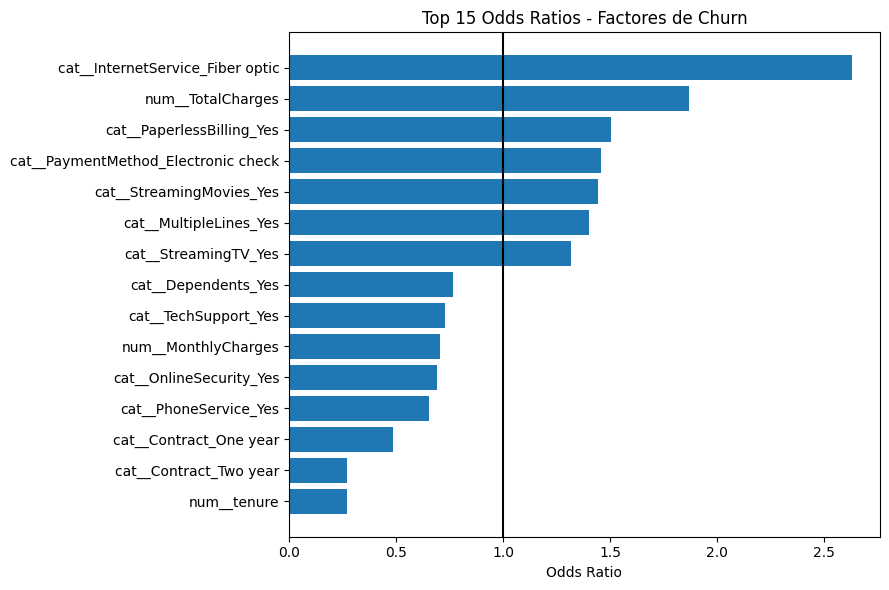

In [ ]:
# ============================================
# PASO 8: Odds Ratios e interpretación
# ============================================

feature_names = log_pipe.named_steps['prep'].get_feature_names_out()
coefs = log_pipe.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': coefs,
    'Odds_Ratio': np.exp(coefs)
}).sort_values('Coefficient', key=abs, ascending=False)

print('\n' + '='*50)
print('TOP 15 ODDS RATIOS')
print('='*50)
print(coef_df.head(15))

top15 = coef_df.head(15).sort_values('Odds_Ratio')
plt.figure(figsize=(9, 6))
plt.barh(top15['Variable'], top15['Odds_Ratio'])
plt.axvline(1, color='black', linestyle='-')
plt.title('Top 15 Odds Ratios - Factores de Churn')
plt.xlabel('Odds Ratio')
plt.tight_layout()
plt.show()



## Paso 9. Comparación de modelos



COMPARACIÓN DE MODELOS
                Modelo  Accuracy  Precision    Recall        F1       AUC
0                 k-NN  0.795078   0.624514  0.572193  0.597209  0.831493
1  Regresión Logística  0.808329   0.665957  0.557932  0.607177  0.844761


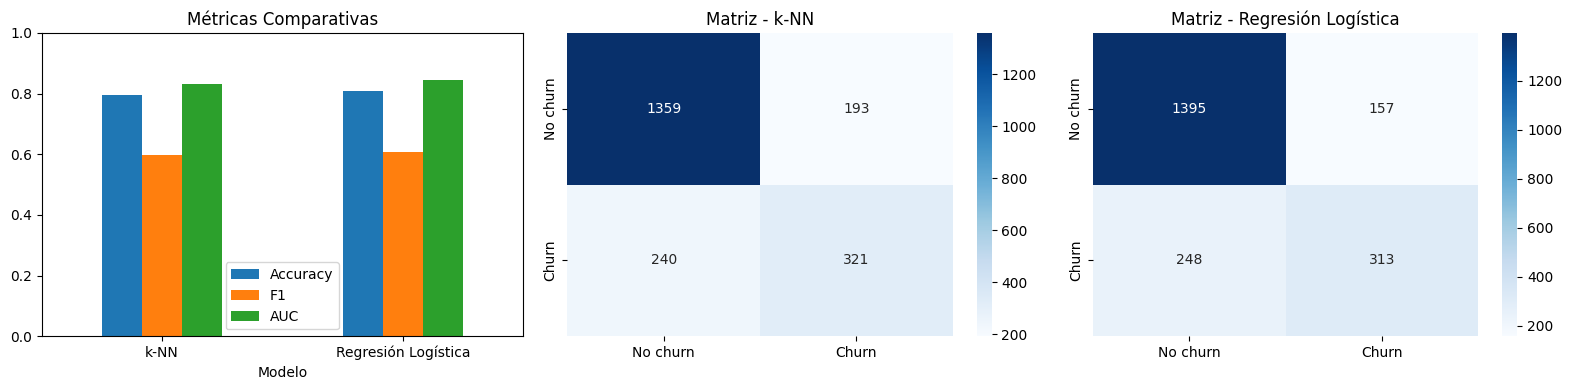

In [ ]:
# ============================================
# PASO 9: Comparación de modelos
# ============================================

results = pd.DataFrame([
    {'Modelo': 'k-NN',
     'Accuracy': accuracy_score(y_test, y_pred_knn),
     'Precision': precision_score(y_test, y_pred_knn),
     'Recall': recall_score(y_test, y_pred_knn),
     'F1': f1_score(y_test, y_pred_knn),
     'AUC': roc_auc_score(y_test, y_prob_knn)},
    {'Modelo': 'Regresión Logística',
     'Accuracy': accuracy_score(y_test, y_pred_log),
     'Precision': precision_score(y_test, y_pred_log),
     'Recall': recall_score(y_test, y_pred_log),
     'F1': f1_score(y_test, y_pred_log),
     'AUC': roc_auc_score(y_test, y_prob_log)}
])

print('\n' + '='*50)
print('COMPARACIÓN DE MODELOS')
print('='*50)
print(results)

# Gráfico de barras
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

results.set_index('Modelo')[['Accuracy', 'F1', 'AUC']].plot(kind='bar', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Métricas Comparativas')
axes[0].tick_params(axis='x', rotation=0)

# Matrices de confusión - CORREGIDO
for ax, name, pred in [(axes[1], 'k-NN', y_pred_knn), (axes[2], 'Regresión Logística', y_pred_log)]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No churn', 'Churn'],
                yticklabels=['No churn', 'Churn'])
    ax.set_title(f'Matriz - {name}')

plt.tight_layout()
plt.show()



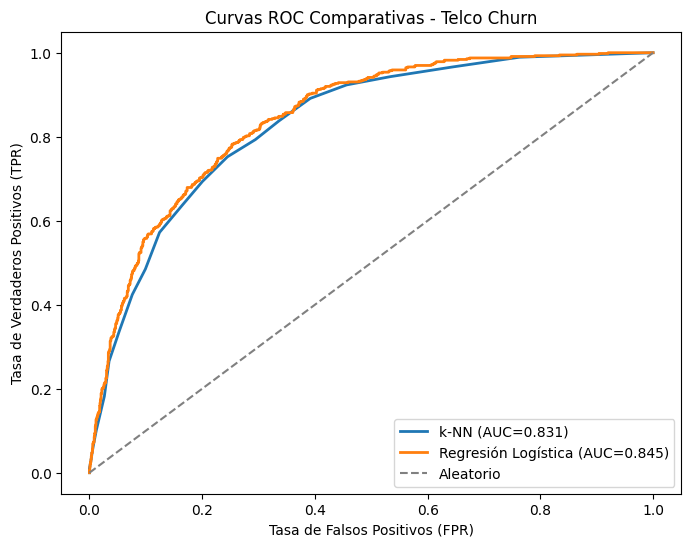

In [ ]:
# ============================================
# PASO 10: Curvas ROC comparativas
# ============================================

plt.figure(figsize=(8, 6))

for name, probs in [('k-NN', y_prob_knn), ('Regresión Logística', y_prob_log)]:  # ← CORREGIDO: "k-NN" no "k-NW"
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Comparativas - Telco Churn')
plt.legend()
plt.show()



## Reflexión final
1. *¿Qué modelo recomendarías a la empresa?*

Recomiendo el modelo de Regresión Logística. Aunque k-NN tiene un F1-Score ligeramente superior (0.597 vs 0.607 para Reg. Logística), la diferencia es mínima. La Regresión Logística ofrece una ventaja crucial: interpretabilidad. Los odds ratios permiten identificar qué factores de riesgo (como Contract_Two year o InternetService_Fiber optic) son más relevantes para el churn, lo cual es fundamental para diseñar campañas de retención efectivas. Además, su AUC (0.845) es ligeramente mejor que el de k-NN (0.831), indicando una capacidad de discriminación superior.

2. *¿Qué error es más costoso en churn?*
El error más costoso es el Falso Negativo (FN). Un FN ocurre cuando el modelo predice que un cliente no hará churn, pero en realidad sí lo hace. Las consecuencias son:

*   El equipo de retención no contacta al cliente.
*   TelcoPerú pierde el contrato completo.
*   Costo: S/ 325 por cliente (pérdida total).

En cambio, un Falso Positivo (FP) solo genera una oferta de retención innecesaria, con un costo de S/ 25 por cliente.


3. *¿Qué variables son más útiles para diseñar campañas de retención?*

Basado en los Odds Ratios de la Regresión Logística, las variables más útiles son:

| Variable | Odds Ratio | Efecto | Acción de retención |
|---|---|---|---|
| Contract_Two year | 0.27 | Reduce drásticamente el riesgo | Ofrecer contratos anuales o bianuales, con descuentos por permanencia. |
| tenure (meses) | 0.27 | Reduce el riesgo | Programas de fidelización que se activen a partir del primer año. |
| InternetService_Fiber optic | 2.63 | Aumenta el riesgo | Monitorear calidad del servicio, ofrecer mejoras o descuentos en fibra óptica. |
| PaperlessBilling_Yes | 1.51 | Aumenta el riesgo | Aunque parece contradictorio, podría indicar menor involucración; campañas de contacto personalizado. |
| PaymentMethod_Electronic check | 1.46 | Aumenta el riesgo | Ofrecer incentivos para migrar a débito automático o transferencia bancaria. |

Estrategias concretas para campañas:

*   Clientes con contrato mes a mes son los de mayor riesgo → ofrecer upgrade a contrato anual con descuento.
*   Clientes con fibra óptica → monitorear y mejorar calidad del servicio; ofrecer paquetes con servicios adicionales.
*   Clientes nuevos (bajo tenure) → campañas de onboarding y beneficios tempranos.
*   Clientes con pago electrónico → incentivar métodos de pago automáticos para reducir fricción.
